# Example of a Factory Acceptance Test

This example ilustrates the whole process. From compute, convert, check and report a performance test.

In [14]:
from pump import *

## General info

In [15]:
water = Fluid(
        name="Water",
        density=Q_(1000, "kg/m**3")
    )

oil = Fluid(
    name="Óleo Combustível",
    density=Q_(1000 * 0.972, "kg/m**3")
    # Please note here the denisty was informed as relative density

)
design_point = DesignPoint(
    fluid=oil,
    capacity=Q_(850, "m**3/h"),
    differential_head=Q_(110.5, "m"),
    NPSH_available=Q_(8.08, "m"),
    speed_of_rotation=Q_(1750, "rpm")
)

## B-432301D

### Computing the test with water

In [16]:
# Instantiating the performance points
capacity = [0.00001, 477.700,	656.580, 856.970, 1085.190, 1284.840, 1541.170]
inlet_pressure = [2.240, 1.968,	1.938,	1.978, 1.988, 1.927, 1.815]
outlet_pressure = [14.031, 13.909, 13.797, 13.560, 12.930, 12.308, 11.550]
load = [209.610, 284.440, 325.370, 394.900, 402.840, 442.100, 501.730]
speed = [1798, 1798, 1798, 1797, 1797, 1797, 1796]
test_points_A = [
    TestPoint(
        fluid=water,
        capacity=Q_(i, "m**3/h"),
        inlet_pressure=Q_(j, "kgf/cm**2"),
        outlet_pressure=Q_(k, "kgf/cm**2"),
        breaking_power=Q_(l, "kW"),
        speed_of_rotation=Q_(m, "rpm"),
        inlet_diameter=Q_(12, "in"),
        outlet_diameter=Q_(10, "in"),
    ) for i, j, k, l, m in zip(capacity, inlet_pressure, outlet_pressure, load, speed)
]

In [17]:
water_curve_A = PerformanceCurve(fluid=water, points=test_points_A)
header = (
    "Capacity\t"
    "Head\t\t"
    "Efficiency\t"
    "Hydr. Power\t"
    "Breaking Power"
)
print(header)
for point in water_curve_A:
    values = (
        f"{point.capacity:6.02f~P}\t"
        f"{point.head:6.02f~P}\t"
        f"{point.efficiency:7.02f~P}\t"
        f"{point.hydraulic_power:7.02f~P}\t"
        f"{point.breaking_power:7.02f~P}"
    )
    print(values)

Capacity	Head		Efficiency	Hydr. Power	Breaking Power
  0.00 m³/h	117.87 m	   0.00 %	   0.00 kW	 209.61 kW
477.70 m³/h	119.55 m	  54.71 %	 155.62 kW	 284.44 kW
656.58 m³/h	118.89 m	  65.38 %	 212.72 kW	 325.37 kW
856.97 m³/h	116.36 m	  68.81 %	 271.74 kW	 394.90 kW
1085.19 m³/h	110.32 m	  80.98 %	 326.22 kW	 402.84 kW
1284.84 m³/h	105.08 m	  83.22 %	 367.92 kW	 442.10 kW
1541.17 m³/h	 99.20 m	  83.03 %	 416.61 kW	 501.73 kW


In [18]:
print(water_curve_A.test_summary)

+--------------+----------+------------------+------------------+--------------+
| Flow         | Head     | Breaking Power   | Hydralic Power   | Efficiency   |
+==============+==========+==================+==================+==============+
| 0.00 m³/h    | 117.87 m | 209.61 kW        | 0.00 kW          | 0.00 %       |
+--------------+----------+------------------+------------------+--------------+
| 477.70 m³/h  | 119.55 m | 284.44 kW        | 155.62 kW        | 54.71 %      |
+--------------+----------+------------------+------------------+--------------+
| 656.58 m³/h  | 118.89 m | 325.37 kW        | 212.72 kW        | 65.38 %      |
+--------------+----------+------------------+------------------+--------------+
| 856.97 m³/h  | 116.36 m | 394.90 kW        | 271.74 kW        | 68.81 %      |
+--------------+----------+------------------+------------------+--------------+
| 1085.19 m³/h | 110.32 m | 402.84 kW        | 326.22 kW        | 80.98 %      |
+--------------+----------+-

### Using a custom polynomial degree
By default the polynomial fit is 4th-order. You can change it via the `polynomial_degree` parameter:

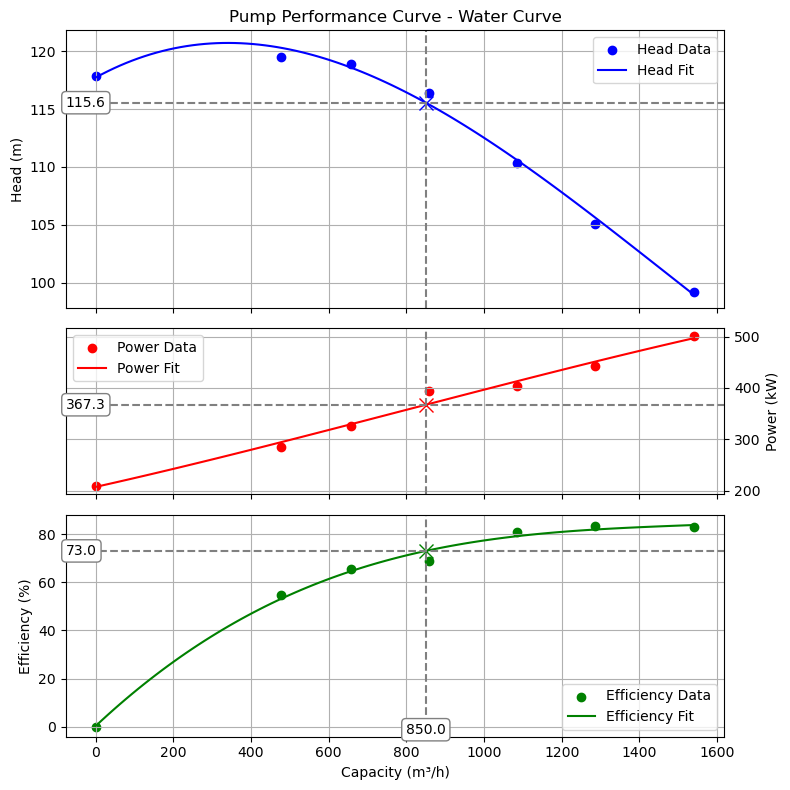

In [19]:
water_curve_A_deg3 = PerformanceCurve(fluid=water, points=test_points_A, polynomial_degree=3)
water_curve_A_deg3.plot_performance_curve(capacity=design_point.capacity)

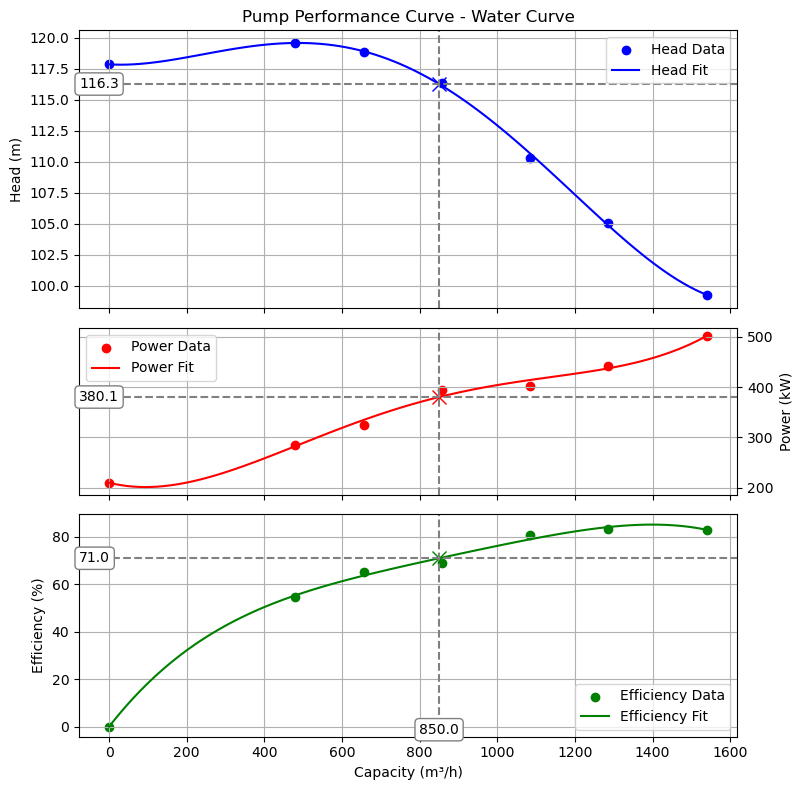

In [20]:
water_curve_A.plot_performance_curve(capacity=design_point.capacity)

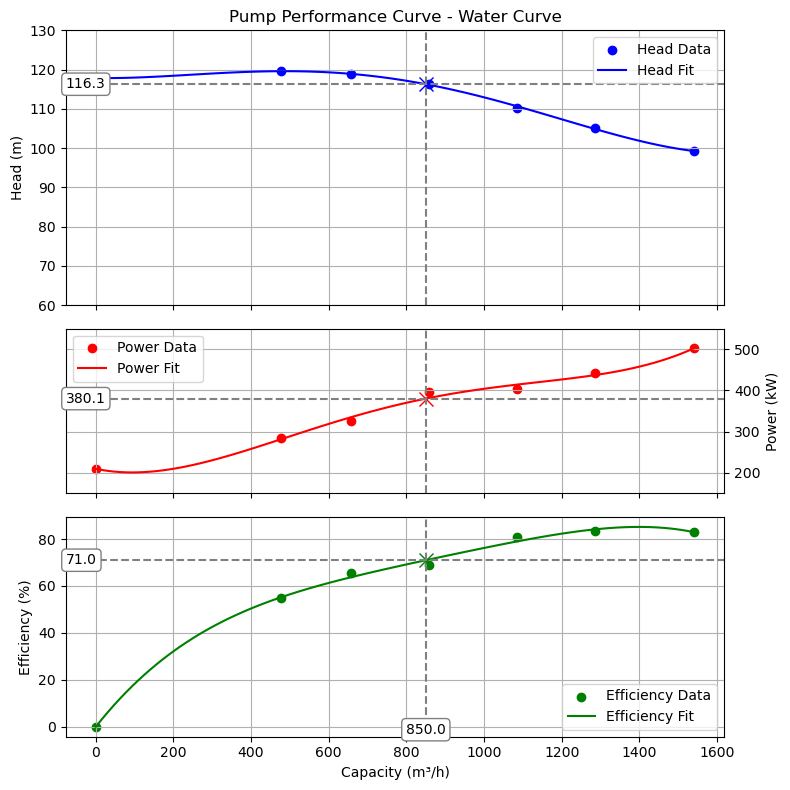

In [21]:
water_curve_A.plot_performance_curve(
    capacity=design_point.capacity,
    head_ylim=(60, 130),
    power_ylim=(150, 550),
)

### Correcting the speed

In [22]:
speed_curve = water_curve_A.to_speed(
    Q_(1750, "rpm")
)
# print(speed_curve.test_summary)

### Density correction

In [23]:
service_curve_A = speed_curve.to_fluid(oil)
print(header)
for point in service_curve_A:
    values = (
        f"{point.capacity:6.02f~P}\t"
        f"{point.head:6.02f~P}\t"
        f"{point.efficiency:7.02f~P}\t"
        f"{point.hydraulic_power:7.02f~P}\t"
        f"{point.breaking_power:7.02f~P}"
    )
    print(values)

Capacity	Head		Efficiency	Hydr. Power	Breaking Power
  0.00 m³/h	111.66 m	   0.00 %	   0.00 kW	 187.86 kW
464.95 m³/h	113.25 m	  54.71 %	 139.47 kW	 254.92 kW
639.05 m³/h	112.63 m	  65.38 %	 190.64 kW	 291.60 kW
834.56 m³/h	110.36 m	  68.81 %	 243.94 kW	 354.51 kW
1056.81 m³/h	104.62 m	  80.98 %	 292.85 kW	 361.63 kW
1251.24 m³/h	 99.66 m	  83.22 %	 330.28 kW	 396.88 kW
1501.70 m³/h	 94.18 m	  83.03 %	 374.62 kW	 451.16 kW


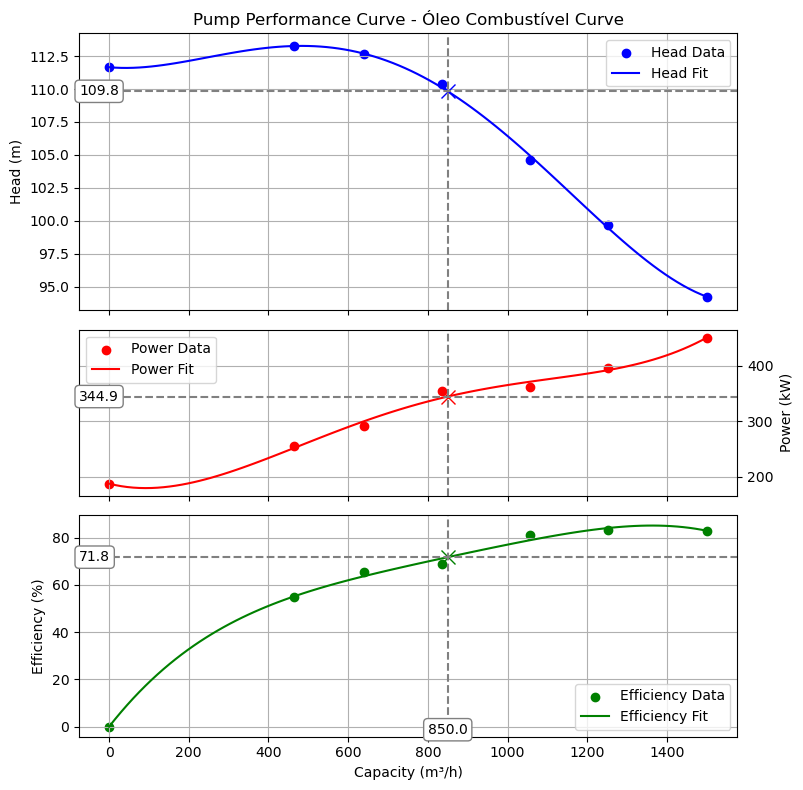

In [24]:
service_curve_A.plot_performance_curve(capacity=design_point.capacity)

### Checking Acceptance

In [25]:
checker_A = PerformanceChecker(design_point, service_curve_A)
print(checker_A.test_summary)

+--------------+----------+------------------+------------------+--------------+
| Flow         | Head     | Breaking Power   | Hydralic Power   | Efficiency   |
+==============+==========+==================+==================+==============+
| 0.00 m³/h    | 111.66 m | 187.86 kW        | 0.00 kW          | 0.00 %       |
+--------------+----------+------------------+------------------+--------------+
| 464.95 m³/h  | 113.25 m | 254.92 kW        | 139.47 kW        | 54.71 %      |
+--------------+----------+------------------+------------------+--------------+
| 639.05 m³/h  | 112.63 m | 291.60 kW        | 190.64 kW        | 65.38 %      |
+--------------+----------+------------------+------------------+--------------+
| 834.56 m³/h  | 110.36 m | 354.51 kW        | 243.94 kW        | 68.81 %      |
+--------------+----------+------------------+------------------+--------------+
| 1056.81 m³/h | 104.62 m | 361.63 kW        | 292.85 kW        | 80.98 %      |
+--------------+----------+-

In [26]:
print(checker_A.test_summary_with_limits)

+--------------+----------+------------+------------+----------------+---------------+---------------+------------------+----------------+
| Flow         | Head     | Head Min   | Head Max   | Shutoff Head   | Shutoff Min   | Shutoff Max   | Breaking Power   | Max B. Power   |
+==============+==========+============+============+================+===============+===============+==================+================+
| 0.00 m³/h    | 111.66 m | 107.19 m   | 113.81 m   | 111.66 m       | N/A           | N/A           | 187.86 kW        | N/A            |
+--------------+----------+------------+------------+----------------+---------------+---------------+------------------+----------------+
| 464.95 m³/h  | 113.25 m | 107.19 m   | 113.81 m   | N/A            | N/A           | N/A           | 254.92 kW        | N/A            |
+--------------+----------+------------+------------+----------------+---------------+---------------+------------------+----------------+
| 639.05 m³/h  | 112.63 m |

## Generating the report

### Organizing the input data

In [27]:
# Step 1: Adding some data
equipament_description = {
    "TAG": "B-432301D",
    "Service": "Bomba de Carregamento de Óleo Combustível",
    "Serial Number": "XPTO",
    "Manufacturer": "XPTO CORPORATION",
    "Model": "HZ 251 7570 / OH2"
}
test_data = {
    "B-21014A" : {
        "Performance Curve - Water" : water_curve_A.plot_performance_curve(capacity=design_point.capacity,return_io=True),
        "Performance Curve - Service Fluid" : service_curve_A.plot_performance_curve(capacity=design_point.capacity, return_io=True),
        "test_summary" : checker_A.report_summary,
        "test_data" : service_curve_A.test_data,
    }
}
# Step 2: Prepare Report Data
report_data = {
    "design_point" : design_point,
    "equipment_description": equipament_description,
    "test_data" : test_data
}

### In Portuguese

In [28]:
report_generator = ReportGenerator(language="pt")
output_filename = report_generator.generate_report(report_data)
print(f"📄 Report generated: {output_filename}")

Novo documento salvo em: Relatório_B-432301D_31-03-2026.docx
📄 Report generated: Relatório_B-432301D_31-03-2026.docx


### In English

In [29]:
report_generator = ReportGenerator(language="en")
output_filename = report_generator.generate_report(report_data)
print(f"📄 Report generated: {output_filename}")

New document saved at: Report_B-432301D_31-03-2026.docx
📄 Report generated: Report_B-432301D_31-03-2026.docx
